### STEP 1 - IMPORT ALL THE NECESSARY LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

-------------------------------------------------------------------------------------------------

### STEP 2 - USE PANDAS LIBRARY IN ORDER TO LOAD THE CSV FILE FROM WHICH WE NEED TO TAKE THE DATA

In [2]:
data = pd.read_csv(
    r"C:\Users\HP\Downloads\Supply_chain (2).csv",
    encoding='latin1'
)


--------------------------------------------------------------------------------------------------------------------------------

### STEP 3 - UNDERSTANDING THE DATASET

In [3]:
data.shape##Purpose1)Returns the number of rows and columns.2)Helps estimate dataset size.

(180519, 53)

In [4]:
data.head() ##Purpose-1)Displays the first five records.2)Verifies that the dataset loaded correctly.3)Provides a quick overview of the columns and sample values.

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,02-03-2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [5]:
data.tail()##Purpose-1)Displays the last five records.2)Confirms the dataset is complete and loaded correctly.3)Helps identify any unusual values near the end of the dataset.

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 18:54,Standard Class


In [6]:
data.describe()##Displays count,mean,standard deviation,minimum,1stQuartile,2nd Quartile(median),3rd Quartile,maximum

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [7]:
data.info()##Purpose-Shows:1)Column names2)Data types3)Missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

-----------------------------------------------------------------------------------------------

### STEP 4 - DATA CLEANING

In [8]:
data.isnull().sum() ##It is used for finding out the missing values

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [9]:
##In order to remove the missing values, we can replace it with mean of the values in that particular column
data.fillna(data.mean(numeric_only=True), inplace=True)##Customer Zipcode

In [10]:
##In order to remove the missing values, we can replace it with mean of the values in that particular column
data.fillna(data.mean(numeric_only=True), inplace=True)##Customer Zipcode

In [11]:
##Again checking for any null values 
data.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      0
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [12]:
data.duplicated().sum()##It is used to tell whether any duplicate values are present or not.

0

In [13]:
##Hence,no duplicate values are present in the dataset.

In [14]:
##Removing unncessary columns that are responsible for making further predictions for future demand of stocks
data.drop(["Product Description","Customer Email","Customer Password"],axis=1,inplace=True)

In [15]:
##Removing the rest unnecessary columns
columns_to_drop = [
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Customer Id',
    'Department Id',
    'Department Name',
    'Order Customer Id',
    'Order Id',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Product Card Id',
    'Product Category Id',
    'Product Image',
    'Product Name',
    'Latitude',
    'Longitude'
]

data.drop(columns=columns_to_drop, inplace=True)

In [16]:
##Here,we are converting the order date and shipping date to "datetime" data
##It is because when we check the datatype of both the columns it would give "object" datatype and pandas would not be able to understand the following details:
## 1]Which month it is?
## 2]Which day it is?
## 3]Which year it is?
## Hence, we will not be able to perform date time calculations

data['order date (DateOrders)'] = pd.to_datetime(
    data['order date (DateOrders)'],
    dayfirst=True,
    format='mixed'
)

data['shipping date (DateOrders)'] = pd.to_datetime(
    data['shipping date (DateOrders)'],
    dayfirst=True,
    format='mixed'
)

In [17]:
##Extracting the useful information after converting it into "datetime" format
data['Order_Year'] = data['order date (DateOrders)'].dt.year
data['Order_Month'] = data['order date (DateOrders)'].dt.month
data['Order_Day'] = data['order date (DateOrders)'].dt.day

data['Shipping_Year'] = data['shipping date (DateOrders)'].dt.year
data['Shipping_Month'] = data['shipping date (DateOrders)'].dt.month
data['Shipping_Day'] = data['shipping date (DateOrders)'].dt.day

In [18]:
## Dropping the original columns
data.drop(
    ['order date (DateOrders)', 'shipping date (DateOrders)'],
    axis=1,
    inplace=True
)

In [19]:
##Removing columns with higher cardinality
high_cardinality_cols = [
    'Customer City',
    'Order City',
    'Customer Country',
    'Order Region'
    'Customer State',
    'Order Country',
    'Order State'
]

data.drop(columns=high_cardinality_cols, inplace=True, errors='ignore')

In [20]:
##Hence,all the unnecessary columns are removed.

In [21]:
categorical_columns = [
    'Type',
    'Delivery Status',
    'Category Name',
    'Customer Segment',
    'Market',
    'Order Status',
    'Shipping Mode',
    'Product Status'
]

data = pd.get_dummies(
    data,
    columns=categorical_columns,
    drop_first=True
)

In [22]:
## Displaying all the columns
data.columns

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Category Id', 'Customer State', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order Zipcode', 'Product Price', 'Order_Year', 'Order_Month',
       'Order_Day', 'Shipping_Year', 'Shipping_Month', 'Shipping_Day',
       'Type_DEBIT', 'Type_PAYMENT', 'Type_TRANSFER',
       'Delivery Status_Late delivery', 'Delivery Status_Shipping canceled',
       'Delivery Status_Shipping on time', 'Category Name_As Seen on  TV!',
       'Category Name_Baby ', 'Category Name_Baseball & Softball',
       'Category Name_Basketball', 'Category Name_Books ',
       'Category Name_Boxing & MMA', 'Category Name_CDs ',
       'Category Name_Cameras ', 'Category Name_Camping & Hiking',

In [23]:
##Checking whether any data type is still object
data.select_dtypes(include='object').columns

Index(['Customer State', 'Order Region'], dtype='object')

In [24]:
### Removing Order Region and Customer State
data.drop(['Order Region','Customer State'], axis=1, inplace=True, errors='ignore')

In [25]:
data.select_dtypes(include='object').columns

Index([], dtype='object')

In [26]:
data.columns

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Category Id', 'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Zipcode', 'Product Price',
       'Order_Year', 'Order_Month', 'Order_Day', 'Shipping_Year',
       'Shipping_Month', 'Shipping_Day', 'Type_DEBIT', 'Type_PAYMENT',
       'Type_TRANSFER', 'Delivery Status_Late delivery',
       'Delivery Status_Shipping canceled', 'Delivery Status_Shipping on time',
       'Category Name_As Seen on  TV!', 'Category Name_Baby ',
       'Category Name_Baseball & Softball', 'Category Name_Basketball',
       'Category Name_Books ', 'Category Name_Boxing & MMA',
       'Category Name_CDs ', 'Category Name_Cameras ',
       'Category Name_Camping & Hiking', 'Category Name_Cardio Equipment',

In [27]:
##Hence,all the unnecessary columns removed and one hot encoding completed.

-------------------------------------------------------------------------------------

### STEP 5 - EXPLORATORY DATA ANALYSIS

#### EDA helps understand the dataset before building the model.

### 1.Histogram

#### A histogram helps us visualize the distribution of inventory values, such as current stock or sales. It shows how many products fall within different stock ranges. This allows us to identify products with very low stock (which may lead to understocking) and very high stock (which may lead to overstocking). While the histogram itself does not prevent these issues, it provides insights that support better forecasting and inventory management decisions.

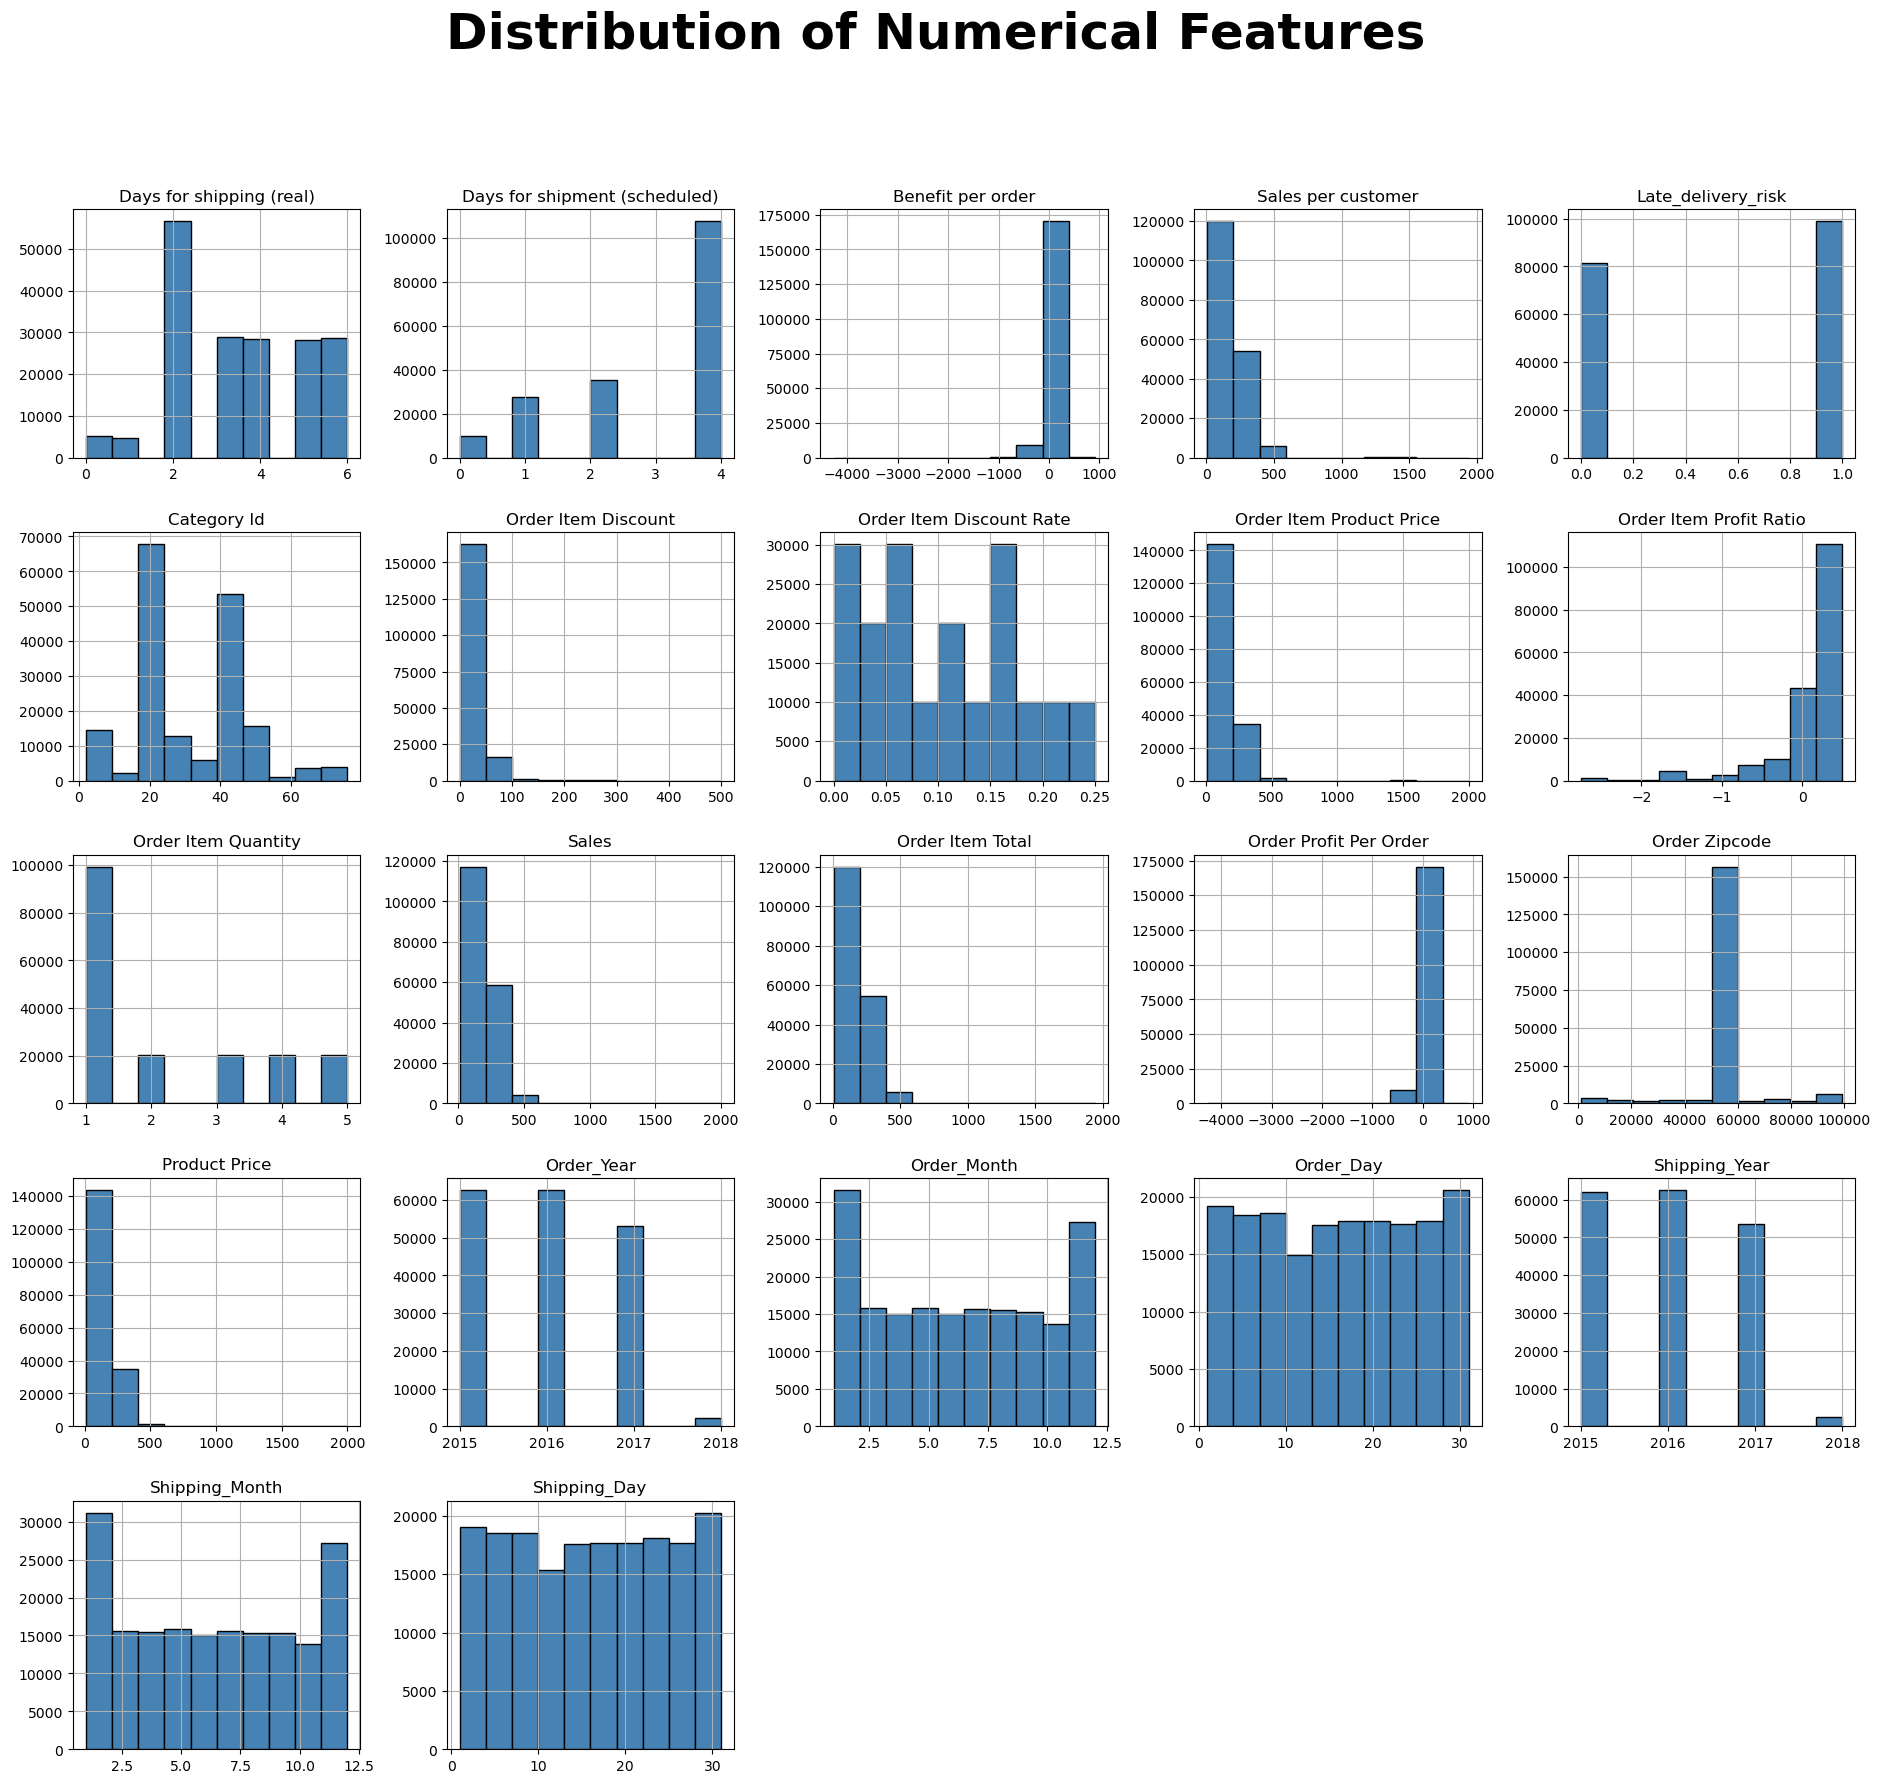

In [28]:
data.hist(figsize=(23,20),color='steelblue',edgecolor="black",bins=10)
plt.suptitle("Distribution of Numerical Features", fontsize=36, fontweight='bold')

plt.grid(color="gray")
plt.show()


### 2.Box Plot

#### A box plot is used to detect outliers and understand the spread of numerical data.

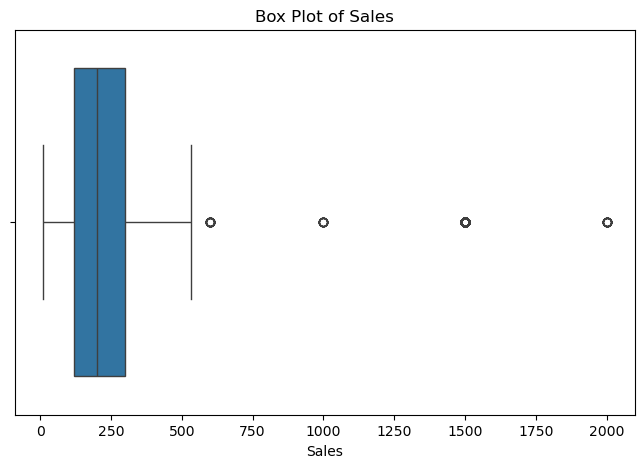

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["Sales"])
plt.title("Box Plot of Sales")
plt.show()

#### 3.Scatter Plot

#### Shows the relationship between two numerical variables.

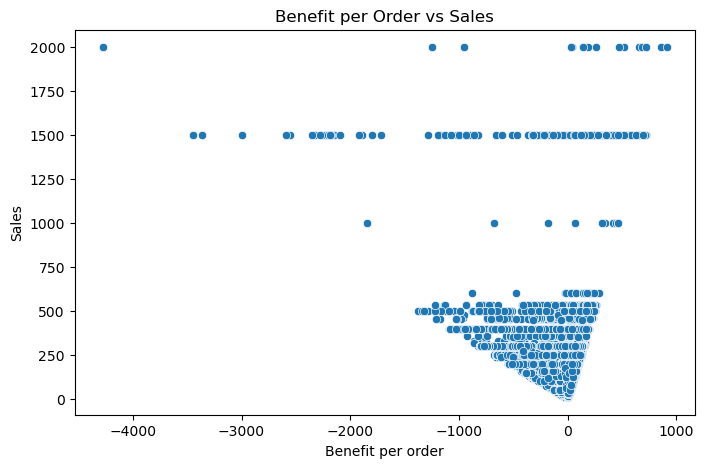

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data,
                x="Benefit per order",
                y="Sales")

plt.title("Benefit per Order vs Sales")
plt.show()

-----------------------------------------------------------------------------------------------------

In [32]:
data.columns

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Category Id', 'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Zipcode', 'Product Price',
       'Order_Year', 'Order_Month', 'Order_Day', 'Shipping_Year',
       'Shipping_Month', 'Shipping_Day', 'Type_DEBIT', 'Type_PAYMENT',
       'Type_TRANSFER', 'Delivery Status_Late delivery',
       'Delivery Status_Shipping canceled', 'Delivery Status_Shipping on time',
       'Category Name_As Seen on  TV!', 'Category Name_Baby ',
       'Category Name_Baseball & Softball', 'Category Name_Basketball',
       'Category Name_Books ', 'Category Name_Boxing & MMA',
       'Category Name_CDs ', 'Category Name_Cameras ',
       'Category Name_Camping & Hiking', 'Category Name_Cardio Equipment',

### MONTHLY DEMAND DATASET

In [33]:
monthly_data = data.groupby(
    ["Order_Year", "Order_Month", "Category Id"]
).agg({

    "Order Item Quantity":"sum",

    "Product Price":"mean",

    "Order Item Discount":"mean",

    "Order Item Discount Rate":"mean",

    "Days for shipping (real)":"mean",

    "Days for shipment (scheduled)":"mean",

    "Late_delivery_risk":"mean"

}).reset_index()

In [35]:
monthly_data.rename(
    columns={
        "Order Item Quantity":"Monthly_Demand"
    },
    inplace=True
)

In [36]:
monthly_data.head()

,Order_Year,Order_Month,Category Id,Monthly_Demand,Product Price,Order Item Discount,Order Item Discount Rate,Days for shipping (real),Days for shipment (scheduled),Late_delivery_risk
0,2015,1,3,90,51.990002,18.401600,0.106800,3.760000,2.760000,0.680000
1,2015,1,5,35,24.990000,9.405454,0.123636,4.727273,4.000000,0.636364
2,2015,1,6,60,44.990002,12.286667,0.090476,3.285714,2.666667,0.666667
3,2015,1,7,54,24.117647,8.227647,0.108824,3.764706,3.176471,0.588235
4,2015,1,9,1159,98.030990,28.909949,0.102392,3.610687,2.954198,0.567430


--------------------------------------------------------------------------------------------

### STEP 6 - Defining the features and the target variable

In [37]:
X = monthly_data.drop("Monthly_Demand",axis=1)##Represents the features
Y = monthly_data["Monthly_Demand"]##Represent the target variable

--------------------------------------------------------------

### STEP 7 - Splitting the training and the testing data

In [38]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)##Testing Data-20% and Training Data-80%

----------------------------------------------------------------------------------------------

### STEP 8 - Creating random forest regression model

In [39]:
rf_model = RandomForestRegressor(n_estimators=200,random_state=42)

--------------------------------------------------------------------

### STEP 9 - Training the model

In [40]:
rf_model.fit(X_train,Y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

-----------------------------------------------------------------------------

### STEP 9 - Predicting test demand

In [41]:
Y_pred = rf_model.predict(X_test)

-------------------------------------------------------------------------------

### STEP 10 - ***Evaluating the model(Model Evaluation)

In [42]:
mae = mean_absolute_error(Y_test,Y_pred)
print("Mean Absolute Error(MAE):",mae)

Mean Absolute Error(MAE): 103.27647887323944


In [43]:
rmse = np.sqrt(mean_squared_error(Y_test,Y_pred))
print("Root Mean Squared Error(RMSE):",rmse)

Root Mean Squared Error(RMSE): 237.16160363254141


In [44]:
r2 = r2_score(Y_test,Y_pred)
print("R2 Score:",r2)

R2 Score: 0.849519993390838


----------------------------------------------------------

### STEP 11 - Preventing Data Leakage

In [45]:
remove_columns = ["Monthly_Demand","Days for shipping (real)","Late_delivery_risk"]
data_new = monthly_data.drop(remove_columns, axis=1)

----------------------------------------------------------------

### STEP 12 - Again,training and testing the model

In [46]:
X = monthly_data.drop(
    ["Monthly_Demand",
     "Days for shipping (real)",
     "Late_delivery_risk"],
    axis=1
)

Y = monthly_data["Monthly_Demand"]

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

rf_model = RandomForestRegressor(n_estimators=200,random_state=42)

rf_model.fit(X_train,Y_train)

Y_pred = rf_model.predict(X_test)

--------------------------------------------------------------------------

### STEP 13 - Checking the new performance

In [47]:
print("Mean Absolute Error(MAE):",mean_absolute_error(Y_test,Y_pred))

print("Root Mean Squared Error(RMSE):",np.sqrt(mean_squared_error(Y_test,Y_pred)))

print("R2 Score:",r2_score(Y_test,Y_pred))

Mean Absolute Error(MAE): 104.61795774647888
Root Mean Squared Error(RMSE): 238.17022835075878
R2 Score: 0.8482373186239706


--------------------------------------------------------------------------

### Step 14 - HYPERPARAMETER TUNING

In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, Y_train)

print("Best Parameters:", grid.best_params_)

best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [49]:
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 105.26921403385154
Root Mean Squared Error (RMSE): 236.75188275786255
R² Score: 0.8500394834052956


-----------------------------------------------------------------------------

### STEP 14 - Feature Importance

#### Feature Importance identifies the key factors influencing demand prediction. Using Random Forest, the contribution of each feature is measured based on its impact on reducing prediction error. The important features help understand demand patterns and support better inventory management decisions such as stock planning and reorder optimization.

In [50]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                         Feature  Importance
3                  Product Price    0.390845
5       Order Item Discount Rate    0.230313
4            Order Item Discount    0.180153
2                    Category Id    0.136877
0                     Order_Year    0.034441
6  Days for shipment (scheduled)    0.020710
1                    Order_Month    0.006660


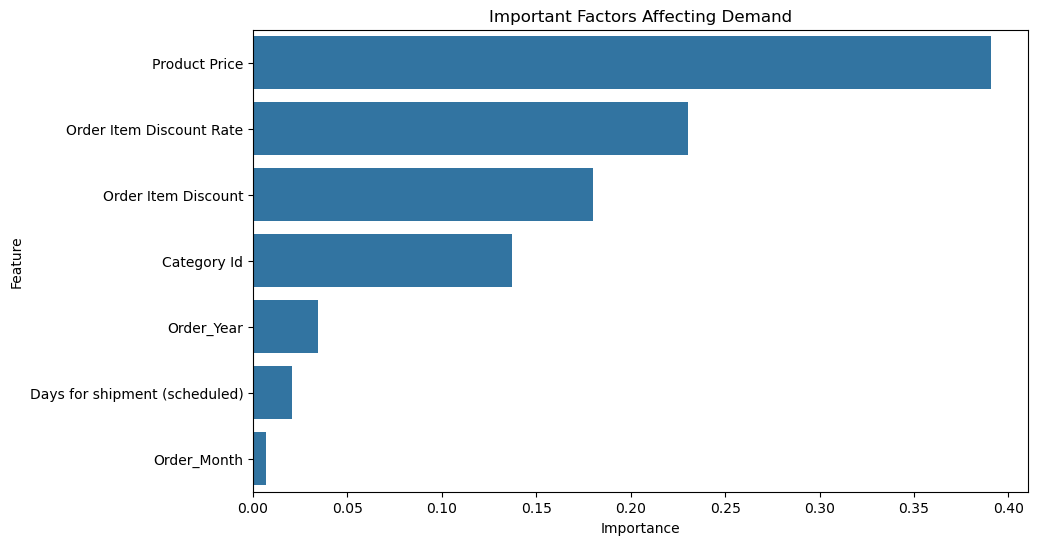

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Important Factors Affecting Demand")

plt.show()

-------------------------------------------------------------

### STEP 15 - Predicting Future Demand

In [52]:
future_data = pd.DataFrame({
    "Order_Year":[2018],
    "Order_Month":[1],
    "Category Id":[17],
    "Product Price":[600],
    "Order Item Discount":[80],
    "Order Item Discount Rate":[0.15],
    "Days for shipment (scheduled)":[4]
})

In [53]:
future_demand = best_rf.predict(future_data)

print("Predicted Monthly Demand:",round(future_demand[0]))

Predicted Monthly Demand: 35


----------------------------------------------------------

### STEP 16 - INVENTORY OPTIMISATION

#### 1.SAFETY STOCK

##### Safety Stock is extra inventory kept as a buffer against uncertainty.

In [54]:
average_daily_demand = future_demand[0] / 30

safety_days = 3

safety_stock = average_daily_demand * safety_days

print("Safety Stock: ",round(safety_stock),"units")


Safety Stock:  3 units


#### 2.AVERAGE DAILY DEMAND

##### Average Daily Demand tells us how many units are expected to be sold/required per day.

In [55]:
average_daily_demand = future_demand[0] / 30
print("Average Daily Demand:", round(average_daily_demand, 2))

Average Daily Demand: 1.15


#### 3.REORDER POINT

##### Reorder Point is the minimum inventory level at which a new order should be placed.

In [56]:
lead_time = 5
reorder_point = (average_daily_demand * lead_time) + safety_stock
print("Reorder Point:", round(reorder_point))

Reorder Point: 9


#### If inventory falls to 9 units or below, the company should reorder stock to avoid running out of products.

----------------------------------------------------------------------------------

### DECISION MAKING

In [57]:
##Suppose current inventory is 8
current_inventory = 8
if current_inventory <= reorder_point:
    print("⚠️ Reorder Required")
    print("Order Quantity:", round(future_demand[0] - current_inventory))
else:
    print("✅ Stock Level is Safe")

⚠️ Reorder Required
Order Quantity: 27
